In [ ]:
import osmnx as ox

place_name = "Jakarta, Indonesia"

print(f"Downloading street network for {place_name}...")

G = ox.graph_from_place(place_name, network_type='drive')

print(f"Successfully downloaded graph!")
print(G)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x73e388145820>>
Traceback (most recent call last):
  File "/home/spatialuser/miniconda3/envs/mapedia/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [ ]:
import osmnx as ox

def get_graph_bounds(G):
    """
    Returns the bounding box of a NetworkX/OSMnx graph.

    Parameters
    ----------
    G : networkx.Graph or DiGraph
        OSMnx or similar road network graph

    Returns
    -------
    bounds : dict
        Dictionary with min/max latitude and longitude
    """
    xs = [data["x"] for _, data in G.nodes(data=True)]
    ys = [data["y"] for _, data in G.nodes(data=True)]
    
    bounds = {
        "min_lon": min(xs),
        "max_lon": max(xs),
        "min_lat": min(ys),
        "max_lat": max(ys)
    }
    return bounds

bounds = get_graph_bounds(G)
print("Graph bounds:", bounds)

In [1]:
import sys
sys.path.append('/home/spatialuser/websites/mapedia')

In [2]:
# Replica 1
from modules import DBHandler

db_handler = DBHandler()
db_handler.connect_to_db()
G = db_handler.get_graph(
    min_lat= -6.3725962,
    max_lat= -6.0785515,
    min_lon= 106.686105,
    max_lon= 106.9737509
)

In [3]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

Plotting graph...


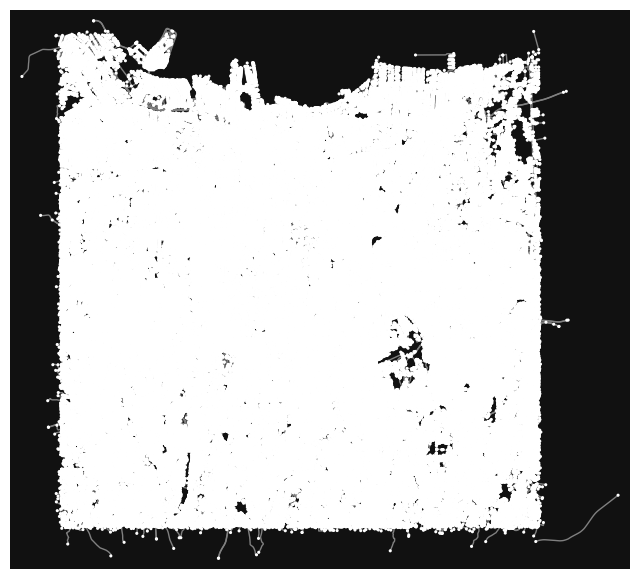

In [4]:
import matplotlib.pyplot as plt
import osmnx as ox
print("Plotting graph...")
fig, ax = ox.plot_graph(G, show=False, close=False,  node_size=5, edge_color='gray')
plt.show()

In [5]:
# Get the first node's ID and its attributes
first_node_data = list(G.nodes(data=True))[0]
print(first_node_data)

(56381, {'x': 106.8273935, 'y': -6.2279677})


In [6]:
# Get the first edge's data (start_node, end_node, key, attributes)
first_edge_data = list(G.edges(data=True, keys=True))[4676]
print(first_edge_data)

(47268, 392871, 0, {'id': 453040, 'osmid': 975614640, 'maxspeed': 50.0, 'oneway': 'UNKNOWN', 'length': 27.071356871075295, 'geometry': <LINESTRING (107 -6.12, 107 -6.12, 107 -6.12, 107 -6.12, 107 -6.12)>})


In [7]:
import osmnx as ox
import pandas as pd
import numpy as np 

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

gdf_edges = gdf_edges.reset_index()

print("--- Edge DataFrame Info (shows non-null counts) ---")
gdf_edges.info()

# Get an exact count of missing values for each column
print("\n--- Count of Missing Values per Column ---")
print(gdf_edges.isnull().sum())

--- Edge DataFrame Info (shows non-null counts) ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 474075 entries, 0 to 474074
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   u         474075 non-null  int64   
 1   v         474075 non-null  int64   
 2   key       474075 non-null  int64   
 3   id        474075 non-null  int64   
 4   osmid     474075 non-null  int64   
 5   maxspeed  474075 non-null  float64 
 6   oneway    474075 non-null  object  
 7   length    474075 non-null  float64 
 8   geometry  474075 non-null  geometry
dtypes: float64(2), geometry(1), int64(5), object(1)
memory usage: 32.6+ MB

--- Count of Missing Values per Column ---
u           0
v           0
key         0
id          0
osmid       0
maxspeed    0
oneway      0
length      0
geometry    0
dtype: int64


In [8]:
gdf_edges.id.value_counts()

id
528806    1
1         1
36373     1
2         1
5935      1
         ..
36811     1
463109    1
12        1
290916    1
13        1
Name: count, Length: 474075, dtype: int64

In [9]:
print(gdf_edges["maxspeed"].value_counts())

maxspeed
50.0     466857
20.0       1726
30.0       1025
10.0        913
40.0        786
80.0        753
5.0         707
60.0        606
25.0        419
100.0       229
15.0         26
45.0         25
3.0           3
Name: count, dtype: int64


In [10]:
# gdf_edges.rename(columns={"osm_id": "osmid"}, inplace=True)

In [11]:
import psycopg2
from sqlalchemy import create_engine, text
import sys

# --- Configuration ---
DB_HOST = 'cs-u-spatial-406.cs.umn.edu'
DB_NAME = 'gis'
DB_USER = 'gis'
DB_PASS = 'gis'
DB_PORT = 5432

# Setup the connection 
connection_str = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_str)

with engine.connect() as connection:
    
    result = connection.execute(text("SELECT * FROM road_attributes LIMIT 0"))
    columns = result.keys()
    
    print("--- Columns in 'road_attributes' table ---")
    for col in columns:
        print(col)

--- Columns in 'road_attributes' table ---
osm_id
oneway
road_type
width
nlanes
max_speed
min_speed
avg_speed
oneway_source
road_type_source
width_source
nlanes_source
max_speed_source
min_speed_source
avg_speed_source
oneway_conf
road_type_conf
width_conf
nlanes_conf
max_speed_conf
min_speed_conf
avg_speed_conf
geometry
id


In [12]:
import psycopg2
from sqlalchemy import create_engine, text
import sys

# --- Configuration ---
DB_HOST = 'cs-u-spatial-406.cs.umn.edu'
DB_NAME = 'gis'
DB_USER = 'gis'
DB_PASS = 'gis'
DB_PORT = 5432


connection_str = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_str)

def simplify_id(val):
    if isinstance(val, list):
        return val[0] # Take the first ID if it's a list
    return val

# Apply it to the osmid column
gdf_edges['osmid'] = gdf_edges['osmid'].apply(simplify_id)

# Get the list of OSM IDs from local DataFrame
# Ensure they are integers
ids_to_fetch = gdf_edges['osmid'].astype(int).unique().tolist()

print(f"Looking up {len(ids_to_fetch)} unique OSM IDs in the remote database...")

# Define a function to fetch data in chunks to avoid crashing the query
def fetch_attributes_in_chunks(id_list, chunk_size=1_000_000):
    all_results = []
    
    # Loop through the IDs in steps of 'chunk_size'
    for i in range(0, len(id_list), chunk_size):
        chunk = id_list[i : i + chunk_size]
        
        # Format the IDs for SQL (e.g., "123, 456, 789")
        ids_tuple = str(tuple(chunk)).replace(',)', ')') # Handle single-element tuple quirk
        
        # Query: Select only the columns we need
        query = f"""
            SELECT id, osm_id, nlanes, width, max_speed, min_speed, oneway, road_type
            FROM road_attributes 
            WHERE osm_id IN {ids_tuple}
        """
        
        # Run query and append to list
        chunk_df = pd.read_sql(query, engine)
        all_results.append(chunk_df)
        
        print(f"  Fetched batch {i} to {i+chunk_size}...")

    # Combine all chunks into one DataFrame
    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return pd.DataFrame()

# Execute the fetch
db_data = fetch_attributes_in_chunks(ids_to_fetch)

# Clean up the external data before merging
# Rename columns to match your 'osmnx' DataFrame for easier merging later
db_data = db_data.rename(columns={
    'osm_id': 'osmid',
    'nlanes': 'lanes_db',
    'width': 'width_db',
    'max_speed': 'maxspeed_db',
    'min_speed': 'minspeed_db',
    'oneway': 'oneway_db',
    'road_type': 'road_type_db'
})

# Ensure osmid is the same type (string/object) as your local df for merging
db_data['osmid'] = db_data['osmid'].astype(str)

print(f"\nSuccessfully retrieved {len(db_data)} rows from the database.")
print(db_data.head())

Looking up 267498 unique OSM IDs in the remote database...
  Fetched batch 0 to 1000000...

Successfully retrieved 261425 rows from the database.
        id    osmid  lanes_db  width_db  maxspeed_db  minspeed_db  oneway_db  \
0   282662  4705040       4.0      12.0          NaN          NaN        1.0   
1   282663  4705043       1.0       4.0          NaN          NaN        1.0   
2   282664  4705045       4.0      10.0          NaN          NaN        1.0   
3   282665  4705046       2.0       6.0          NaN          NaN        1.0   
4  2315577  8151584       2.0       7.0          NaN          NaN        1.0   

   road_type_db  
0           3.0  
1           2.0  
2           2.0  
3           2.0  
4           2.0  


In [13]:
db_data.id.nunique()

261425

In [14]:
db_data

,id,osmid,lanes_db,width_db,maxspeed_db,minspeed_db,oneway_db,road_type_db
0,282662,4705040,4.0,12.0,NaN,NaN,1.0,3.0
1,282663,4705043,1.0,4.0,NaN,NaN,1.0,2.0
2,282664,4705045,4.0,10.0,NaN,NaN,1.0,2.0
3,282665,4705046,2.0,6.0,NaN,NaN,1.0,2.0
4,2315577,8151584,2.0,7.0,NaN,NaN,1.0,2.0
...,...,...,...,...,...,...,...,...
261420,221029459,1410469727,NaN,NaN,NaN,NaN,NaN,1.0
261421,221033669,1410497907,NaN,NaN,NaN,NaN,NaN,1.0
261422,221033670,1410497908,1.0,1.0,NaN,NaN,0.0,1.0
261423,221033718,1410498386,1.0,2.0,NaN,NaN,0.0,1.0


In [15]:
print(db_data.info())

print(gdf_edges.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261425 entries, 0 to 261424
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            261425 non-null  int64  
 1   osmid         261425 non-null  object 
 2   lanes_db      104582 non-null  float64
 3   width_db      85515 non-null   float64
 4   maxspeed_db   3217 non-null    float64
 5   minspeed_db   571 non-null     float64
 6   oneway_db     111247 non-null  float64
 7   road_type_db  258598 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 16.0+ MB
None
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 474075 entries, 0 to 474074
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   u         474075 non-null  int64   
 1   v         474075 non-null  int64   
 2   key       474075 non-null  int64   
 3   id        474075 non-null  int64   
 4   osmid     474

In [16]:
# gdf_edges['width'] = gdf_edges['width'].fillna(gdf_edges['est_width']) Will do it lastly
# columns_to_drop = ["junction", "bridge", "access", "ref","tunnel", "reversed", "name"]
# gdf_edges = gdf_edges.drop(columns = columns_to_drop)
# print(gdf_edges.isnull().sum())

In [17]:
# print(gdf_edges["maxspeed"].value_counts())

In [18]:
# print(gdf_edges["lanes"].value_counts())

In [19]:
# for val in gdf_edges["width"].value_counts().index:
#     print(val)

In [20]:
# print(gdf_edges["road_type"].value_counts())

In [21]:
gdf_edges

,u,v,key,id,osmid,maxspeed,oneway,length,geometry
0,56381,34008,0,1,18570808,50.0,YES,29.237214,"LINESTRING (106.83 -6.228, 106.83 -6.2282)"
1,34008,45978,0,36373,18570808,50.0,YES,61.132449,"LINESTRING (106.83 -6.2282, 106.83 -6.2284, 10..."
2,34514,6516,0,2,29482183,50.0,YES,34.480973,"LINESTRING (106.9 -6.1897, 106.9 -6.1894)"
3,34514,12452,0,5935,29482185,50.0,NO,116.963624,"LINESTRING (106.9 -6.1897, 106.89 -6.1898)"
4,6516,58562,0,5939,29482171,50.0,YES,19.309903,"LINESTRING (106.9 -6.1894, 106.9 -6.1893)"
...,...,...,...,...,...,...,...,...,...
474070,419099,421027,0,528767,1280085859,50.0,UNKNOWN,15.087267,"LINESTRING (106.81 -6.1551, 106.81 -6.1553)"
474071,417781,421029,0,528770,1362577940,50.0,UNKNOWN,47.450842,"LINESTRING (106.82 -6.1799, 106.82 -6.1799, 10..."
474072,416831,421040,0,528782,1326434780,50.0,UNKNOWN,21.666166,"LINESTRING (106.9 -6.3229, 106.9 -6.3227)"
474073,418947,421040,0,528783,1326434782,50.0,UNKNOWN,50.482869,"LINESTRING (106.9 -6.3228, 106.9 -6.3227)"


In [22]:
db_data.osmid = db_data.osmid.astype(int)
db_data.id = db_data.id.astype(int)

In [23]:
merged_df = gdf_edges.merge(db_data, on='osmid', how='left')

In [24]:
merged_df.drop(columns=[
    'key',
    'oneway',
    'length',
    'maxspeed'
    ], inplace=True)

In [25]:
merged_df.rename(columns={
    'lanes_db': 'lanes', 
    'width_db': 'width',
    'maxspeed_db': 'maxspeed',
    'minspeed_db': 'minspeed',
    'oneway_db': 'oneway',
    'road_type_db': 'road_type'
    }, inplace=True)
merged_df.head()

,u,v,id_x,osmid,geometry,id_y,lanes,width,maxspeed,minspeed,oneway,road_type
0,56381,34008,1,18570808,"LINESTRING (106.83 -6.228, 106.83 -6.2282)",9650695.0,2.0,NaN,NaN,NaN,NaN,2.0
1,34008,45978,36373,18570808,"LINESTRING (106.83 -6.2282, 106.83 -6.2284, 10...",9650695.0,2.0,NaN,NaN,NaN,NaN,2.0
2,34514,6516,2,29482183,"LINESTRING (106.9 -6.1897, 106.9 -6.1894)",15522253.0,1.0,5.0,NaN,NaN,1.0,1.0
3,34514,12452,5935,29482185,"LINESTRING (106.9 -6.1897, 106.89 -6.1898)",15522255.0,1.0,5.0,NaN,NaN,0.0,1.0
4,6516,58562,5939,29482171,"LINESTRING (106.9 -6.1894, 106.9 -6.1893)",15522243.0,1.0,5.0,NaN,NaN,1.0,1.0


In [26]:
merged_df.rename(columns={'id_y': 'road_id', 'id_x': 'edge_id'}, inplace=True)

In [27]:
merged_df.oneway = merged_df.oneway.map({1.0: True, 0.0: False}).astype("boolean")

In [28]:
merged_df["maxspeed"] = (
    pd.to_numeric(merged_df["maxspeed"], errors="coerce")
      .astype("Int64")   # capital I
)
merged_df["minspeed"] = (
    pd.to_numeric(merged_df["minspeed"], errors="coerce")
      .astype("Int64")   # capital I
)
merged_df["lanes"] = (
    pd.to_numeric(merged_df["lanes"], errors="coerce")
      .astype("Int64")   # capital I
)
merged_df["road_type"] = (
    pd.to_numeric(merged_df["road_type"], errors="coerce")
      .astype("Int64")   # capital I
)

In [29]:
merged_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 474075 entries, 0 to 474074
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   u          474075 non-null  int64   
 1   v          474075 non-null  int64   
 2   edge_id    474075 non-null  int64   
 3   osmid      474075 non-null  int64   
 4   geometry   474075 non-null  geometry
 5   road_id    464203 non-null  float64 
 6   lanes      228981 non-null  Int64   
 7   width      187175 non-null  float64 
 8   maxspeed   7474 non-null    Int64   
 9   minspeed   1304 non-null    Int64   
 10  oneway     228926 non-null  boolean 
 11  road_type  459034 non-null  Int64   
dtypes: Int64(4), boolean(1), float64(2), geometry(1), int64(4)
memory usage: 42.5 MB


In [30]:
print(merged_df.isnull().sum())

u                 0
v                 0
edge_id           0
osmid             0
geometry          0
road_id        9872
lanes        245094
width        286900
maxspeed     466601
minspeed     472771
oneway       245149
road_type     15041
dtype: int64


In [31]:
# 5. Cleanup
# Drop the temporary columns we just used
final_gdf = merged_df #.drop(columns=['maxspeed', 'minspeed'])

print("\n--- Missing Values AFTER Database Fill ---")
print(final_gdf.isnull().sum())


--- Missing Values AFTER Database Fill ---
u                 0
v                 0
edge_id           0
osmid             0
geometry          0
road_id        9872
lanes        245094
width        286900
maxspeed     466601
minspeed     472771
oneway       245149
road_type     15041
dtype: int64


In [32]:
print(final_gdf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 474075 entries, 0 to 474074
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   u          474075 non-null  int64   
 1   v          474075 non-null  int64   
 2   edge_id    474075 non-null  int64   
 3   osmid      474075 non-null  int64   
 4   geometry   474075 non-null  geometry
 5   road_id    464203 non-null  float64 
 6   lanes      228981 non-null  Int64   
 7   width      187175 non-null  float64 
 8   maxspeed   7474 non-null    Int64   
 9   minspeed   1304 non-null    Int64   
 10  oneway     228926 non-null  boolean 
 11  road_type  459034 non-null  Int64   
dtypes: Int64(4), boolean(1), float64(2), geometry(1), int64(4)
memory usage: 42.5 MB
None


In [33]:
final_gdf

,u,v,edge_id,osmid,geometry,road_id,lanes,width,maxspeed,minspeed,oneway,road_type
0,56381,34008,1,18570808,"LINESTRING (106.83 -6.228, 106.83 -6.2282)",9650695.0,2,NaN,<NA>,<NA>,<NA>,2
1,34008,45978,36373,18570808,"LINESTRING (106.83 -6.2282, 106.83 -6.2284, 10...",9650695.0,2,NaN,<NA>,<NA>,<NA>,2
2,34514,6516,2,29482183,"LINESTRING (106.9 -6.1897, 106.9 -6.1894)",15522253.0,1,5.0,<NA>,<NA>,True,1
3,34514,12452,5935,29482185,"LINESTRING (106.9 -6.1897, 106.89 -6.1898)",15522255.0,1,5.0,<NA>,<NA>,False,1
4,6516,58562,5939,29482171,"LINESTRING (106.9 -6.1894, 106.9 -6.1893)",15522243.0,1,5.0,<NA>,<NA>,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
474070,419099,421027,528767,1280085859,"LINESTRING (106.81 -6.1551, 106.81 -6.1553)",206959004.0,<NA>,NaN,<NA>,<NA>,<NA>,1
474071,417781,421029,528770,1362577940,"LINESTRING (106.82 -6.1799, 106.82 -6.1799, 10...",216909896.0,<NA>,NaN,<NA>,<NA>,<NA>,0
474072,416831,421040,528782,1326434780,"LINESTRING (106.9 -6.3229, 106.9 -6.3227)",212508598.0,<NA>,NaN,<NA>,<NA>,<NA>,1
474073,418947,421040,528783,1326434782,"LINESTRING (106.9 -6.3228, 106.9 -6.3227)",212508600.0,<NA>,NaN,<NA>,<NA>,<NA>,1


In [34]:
# final_gdf['width'] = final_gdf['width'].fillna(final_gdf['est_width'])
# final_gdf = final_gdf.drop(columns = ["est_width", "maxspeed"])

In [35]:
print(final_gdf.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 474075 entries, 0 to 474074
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   u          474075 non-null  int64   
 1   v          474075 non-null  int64   
 2   edge_id    474075 non-null  int64   
 3   osmid      474075 non-null  int64   
 4   geometry   474075 non-null  geometry
 5   road_id    464203 non-null  float64 
 6   lanes      228981 non-null  Int64   
 7   width      187175 non-null  float64 
 8   maxspeed   7474 non-null    Int64   
 9   minspeed   1304 non-null    Int64   
 10  oneway     228926 non-null  boolean 
 11  road_type  459034 non-null  Int64   
dtypes: Int64(4), boolean(1), float64(2), geometry(1), int64(4)
memory usage: 42.5 MB
None


In [36]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

class MultiAttrGAT(nn.Module):
    # def __init__(self, num_road_type, rt_emb_dim=16,
    #              lanes_emb_dim=8, oneway_emb_dim=4,
    #              cont_dim=2, hidden=32, heads=2, dropout=0.1):
    def __init__(self, num_road_type, rt_emb_dim=16,
                 lanes_emb_dim=8, oneway_emb_dim=4,
                 cont_dim=1, hidden=32, heads=2, dropout=0.1):
        super().__init__()

        # Embeddings for categorical inputs
        self.rt_emb = nn.Embedding(num_road_type, rt_emb_dim)
        # lanes ids: 0,1,2 + MASK(3) + MISSING(4) => size 5
        self.lanes_emb = nn.Embedding(5, lanes_emb_dim)
        # oneway ids: 0,1 + MASK(2) => size 3
        self.oneway_emb = nn.Embedding(3, oneway_emb_dim)
 
        in_dim = cont_dim + rt_emb_dim + lanes_emb_dim + oneway_emb_dim

        self.gat1 = GATv2Conv(in_dim, hidden, heads=heads, concat=True, dropout=dropout)
        self.gat2 = GATv2Conv(hidden * heads, hidden, heads=heads, concat=False, dropout=dropout)

        # Heads
        self.head_road_type = nn.Linear(hidden, num_road_type)  # CE
        self.head_lanes   = nn.Linear(hidden, 3)            # CE for 3 classes
        self.head_oneway  = nn.Linear(hidden, 1)            # BCE logit
        self.head_width   = nn.Linear(hidden, 1)            # Huber
        # self.head_length  = nn.Linear(hidden, 1)            # Huber

    def forward(self, x_cont, road_type_in, lanes_in, oneway_in, edge_index):
        hwy = self.rt_emb(road_type_in)
        lan = self.lanes_emb(lanes_in)
        onw = self.oneway_emb(oneway_in)

        x = torch.cat([x_cont, hwy, lan, onw], dim=1)

        h = self.gat1(x, edge_index)
        h = F.elu(h)
        h = self.gat2(h, edge_index)
        h = F.elu(h)

        out = {
            "road_type": self.head_road_type(h),
            "lanes":   self.head_lanes(h),
            "oneway":  self.head_oneway(h).squeeze(-1),
            "width":   self.head_width(h).squeeze(-1),
            # "length":  self.head_length(h).squeeze(-1),
        }
        return out

In [37]:
# =========================
# 0) Imports
# =========================
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [38]:
# =========================
# 1) Helpers: parsing & encoding
# =========================

def lanes_to_class(x):
    """
    x: numeric lanes value or NaN
    returns:
      -1 if NaN
       0 for 1 lane
       1 for 2 lanes
       2 for 3+ lanes
    """
    if pd.isna(x):
        return -1
    # If lanes are floats like 1.0, 2.0, 3.0
    v = float(x)

    if v <= 1.0:
        return 0
    elif v <= 2.0:
        return 1
    else:
        return 2

class ZScaler:
    """Z-score scaler that ignores NaN."""
    def __init__(self):
        self.mu = None
        self.sd = None

    def fit(self, x: np.ndarray):
        self.mu = np.nanmean(x)
        self.sd = np.nanstd(x) + 1e-8

    def transform(self, x: np.ndarray):
        return (x - self.mu) / self.sd


In [39]:

# =========================
# 2) Build line graph adjacency from (u,v)
# =========================
def build_line_graph_edge_index(df, u_col="u", v_col="v", eid_col="eid"):
    """
    Nodes in line graph = edges in original graph (df rows).
    Two line-graph nodes connect if original edges share an endpoint (u or v).
    """
    incident = {}
    u_vals = df[u_col].values
    v_vals = df[v_col].values
    eids  = df[eid_col].values

    for u, v, eid in zip(u_vals, v_vals, eids):
        incident.setdefault(u, []).append(eid)
        incident.setdefault(v, []).append(eid)

    pairs = []
    for node, lst in incident.items():
        m = len(lst)
        if m < 2:
            continue
        # clique among incident edges
        for i in range(m):
            for j in range(i + 1, m):
                a, b = lst[i], lst[j]
                pairs.append((a, b))
                pairs.append((b, a))

    edge_index = torch.tensor(pairs, dtype=torch.long).t().contiguous()
    return edge_index


In [40]:

# =========================
# 3) Prepare dataframe: ids, parsing, vocab
# =========================
df = final_gdf.copy()

# Stable node id for line graph nodes
df = df.reset_index(drop=True)
df["eid"] = np.arange(len(df), dtype=np.int64)

# Parse width to float
df["width_m"] = df["width"]

# Lanes class 0/1/2, missing -1
df["lanes_cls"] = df["lanes"].apply(lanes_to_class).astype(np.int64)

# Oneway to 0/1 int
# your final_gdf shows oneway is int64 already; this keeps it safe:
# df["oneway01"] = df["oneway"].fillna(-1).astype(int).astype(np.int64)
df["oneway01"] = (
    df["oneway"]
      .map({True: 1, False: 0})
      .astype("Int64")
)

# road_type categorical vocab (add MASK and UNK)
road_type_vals = df["road_type"].astype(str).fillna("UNK").values
unique_road_types = sorted(pd.unique(road_type_vals).tolist())

MASK_TOKEN = "__MASK__"
UNK_TOKEN  = "__UNK__"

# Ensure UNK exists (in case there were NaNs or unseen later)
if UNK_TOKEN not in unique_road_types:
    unique_road_types.append(UNK_TOKEN)
# Add MASK as special id
if MASK_TOKEN in unique_road_types:
    unique_road_types.remove(MASK_TOKEN)
unique_road_types.append(MASK_TOKEN)
road_type2id = {h:i for i,h in enumerate(unique_road_types)}
id2road_type = {i:h for h,i in road_type2id.items()}

df["road_type_id"] = df["road_type"].astype(str).map(lambda x: road_type2id.get(x, road_type2id[UNK_TOKEN])).astype(np.int64)

# Special IDs
ROAD_TYPE_MASK_ID = road_type2id[MASK_TOKEN]

LANES_MASK_ID = 3   # lanes classes are 0,1,2; reserve 3 for MASK
LANES_MISS_ID = 4   # reserve 4 for MISSING (optional but helpful)

ONEWAY_MASK_VAL = -1  # sentinel in the categorical oneway ids (we'll use embedding-like ids)


In [41]:

# =========================
# 4) Train/Val/Test split (node-level)
# =========================
N = len(df)
perm = np.random.permutation(N)
n_train = int(0.80 * N)
n_val   = int(0.10 * N)

train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train+n_val]
test_idx  = perm[n_train+n_val:]

train_mask = np.zeros(N, dtype=bool); train_mask[train_idx] = True
val_mask   = np.zeros(N, dtype=bool); val_mask[val_idx] = True
test_mask  = np.zeros(N, dtype=bool); test_mask[test_idx] = True


In [42]:

# =========================
# 5) Normalize continuous features (train-only, ignore NaNs)
# =========================
# # Length: log1p then z-score (length appears complete, but we do it generally)
# length_raw = df["length"].to_numpy(dtype=np.float32)
# length_log = np.log1p(length_raw)

width_raw = df["width_m"].to_numpy(dtype=np.float32)  # contains NaN

len_scaler = ZScaler()
wid_scaler = ZScaler()

# len_scaler.fit(length_log[train_idx])
wid_scaler.fit(width_raw[train_idx])  # ignores NaN

# length_z = len_scaler.transform(length_log).astype(np.float32)
width_z  = wid_scaler.transform(width_raw).astype(np.float32)  # NaN stays NaN

# For INPUTS: replace NaN with 0.0 (mask token for continuous)
width_z_in  = np.nan_to_num(width_z, nan=0.0).astype(np.float32)


In [43]:
df["oneway01"] = df["oneway01"].fillna(0) # TODO: Needs to change

In [44]:

# =========================
# 6) Build PyG Data: base inputs + targets
# =========================
# We'll build inputs using:
# - continuous: length_z, width_z_in
# - categorical ids: road_type_id, lanes_input_id, oneway_input_id
#
# For lanes input id: use lanes_cls when present else LANES_MISS_ID
lanes_in_id = df["lanes_cls"].to_numpy(dtype=np.int64)
lanes_in_id = np.where(lanes_in_id == -1, LANES_MISS_ID, lanes_in_id)

# For oneway input id: map 0/1 to 0/1, no missing in your data, but reserve MASK later
oneway_in_id = df["oneway01"].to_numpy(dtype=np.int64)  # 0/1

# Targets
y_road_type = df["road_type_id"].to_numpy(dtype=np.int64)
y_lanes   = df["lanes_cls"].to_numpy(dtype=np.int64)    # -1 for missing
y_oneway  = df["oneway01"].to_numpy(dtype=np.float32)   # BCE expects float 0/1
y_width   = df["width_m"].to_numpy(dtype=np.float32)    # NaN allowed
# y_length  = length_log.astype(np.float32)               # use log1p length as regression target

# Edge index for line graph
edge_index = build_line_graph_edge_index(df, u_col="u", v_col="v", eid_col="eid")
print("Line graph edge_index:", edge_index.shape)

data = Data(
    # continuous base channels (2)
    # x_cont=torch.tensor(np.column_stack([length_z, width_z_in]), dtype=torch.float32),
    x_cont=torch.tensor(np.column_stack([width_z_in]), dtype=torch.float32),
    edge_index=edge_index
)

# Store categorical input ids
data.road_type_in = torch.tensor(df["road_type_id"].to_numpy(dtype=np.int64), dtype=torch.long)
data.lanes_in   = torch.tensor(lanes_in_id, dtype=torch.long)
data.oneway_in  = torch.tensor(oneway_in_id, dtype=torch.long)

# Store targets
data.y_road_type = torch.tensor(y_road_type, dtype=torch.long)
data.y_lanes   = torch.tensor(y_lanes, dtype=torch.long)
data.y_oneway  = torch.tensor(y_oneway, dtype=torch.float32)
data.y_width   = torch.tensor(y_width, dtype=torch.float32)
# data.y_length  = torch.tensor(y_length, dtype=torch.float32)

# Splits
data.train_idx = torch.tensor(train_idx, dtype=torch.long)
data.val_idx   = torch.tensor(val_idx, dtype=torch.long)
data.test_idx  = torch.tensor(test_idx, dtype=torch.long)

# Move static tensors to device later; we will clone inputs per epoch for masking
data = data.to(device)


Line graph edge_index: torch.Size([2, 1711962])


In [45]:
# =========================
# 7) Model: embeddings + 2-layer GATv2Conv + multi-head decoders
# =========================
# from src.models.MultiAttrGAT import MultiAttrGAT

num_road_type = len(road_type2id)
model = MultiAttrGAT(num_road_type=num_road_type).to(device)

# Losses
loss_ce = nn.CrossEntropyLoss()
loss_bce = nn.BCEWithLogitsLoss()
loss_huber = nn.SmoothL1Loss()


In [46]:

# =========================
# 8) Masking utilities (30% per attribute, only on valid, only train nodes)
# =========================
def bernoulli_mask(idx, valid_mask, p=0.3):
    """
    idx: LongTensor of train node indices
    valid_mask: BoolTensor [N] validity
    returns BoolTensor [N] masking positions
    """
    m = torch.zeros_like(valid_mask, dtype=torch.bool)
    # sample only on idx
    r = torch.rand(idx.shape[0], device=idx.device)
    chosen = r < p
    m[idx[chosen]] = True
    # intersect with validity
    m = m & valid_mask
    return m

# Special ids for masking categorical inputs
ONEWAY_MASK_ID = 2  # in the oneway embedding (0,1, MASK=2)

# continuous input column indices
# CONT_LENGTH_COL = 0
CONT_WIDTH_COL  = 1
CONT_WIDTH_COL  = 0 # since we have only width now


In [47]:

# =========================
# 9) Training loop
# =========================
def evaluate(model, data, split_idx, p_mask=0.3):
    """
    Evaluate masked-only reconstruction on a split.
    For evaluation, we create fresh masks on the split and measure metrics on masked positions.
    """
    model.eval()
    with torch.no_grad():
        idx = split_idx

        # Validity masks
        valid_hwy = torch.ones_like(data.y_road_type, dtype=torch.bool)
        valid_lan = (data.y_lanes != -1)
        valid_onw = torch.ones_like(data.y_oneway, dtype=torch.bool)
        valid_wid = ~torch.isnan(data.y_width)
        # valid_len = ~torch.isnan(data.y_length)

        # Create masking positions on this split
        mask_hwy = bernoulli_mask(idx, valid_hwy, p_mask)
        mask_lan = bernoulli_mask(idx, valid_lan, p_mask)
        mask_onw = bernoulli_mask(idx, valid_onw, p_mask)
        mask_wid = bernoulli_mask(idx, valid_wid, p_mask)
        # mask_len = bernoulli_mask(idx, valid_len, p_mask)

        # Corrupt inputs
        x_cont = data.x_cont.clone()
        road_type_in = data.road_type_in.clone()
        lanes_in = data.lanes_in.clone()
        oneway_in = data.oneway_in.clone()

        # categorical mask tokens
        road_type_in[mask_hwy] = ROAD_TYPE_MASK_ID
        lanes_in[mask_lan]   = LANES_MASK_ID
        oneway_in[mask_onw]  = ONEWAY_MASK_ID

        # continuous mask tokens
        x_cont[mask_wid, CONT_WIDTH_COL]  = 0.0
        # x_cont[mask_len, CONT_LENGTH_COL] = 0.0

        pred = model(x_cont, road_type_in, lanes_in, oneway_in, data.edge_index)

        # Metrics (masked-only)
        # road_type accuracy
        hwy_acc = float((pred["road_type"][mask_hwy].argmax(dim=1) == data.y_road_type[mask_hwy]).float().mean()) if mask_hwy.any() else np.nan
        lan_acc = float((pred["lanes"][mask_lan].argmax(dim=1) == data.y_lanes[mask_lan]).float().mean()) if mask_lan.any() else np.nan

        # oneway accuracy
        if mask_onw.any():
            onw_prob = torch.sigmoid(pred["oneway"][mask_onw])
            onw_hat = (onw_prob >= 0.5).float()
            onw_acc = float((onw_hat == data.y_oneway[mask_onw]).float().mean())
        else:
            onw_acc = np.nan

        # width MAE
        wid_mae = float(torch.mean(torch.abs(pred["width"][mask_wid] - data.y_width[mask_wid]))) if mask_wid.any() else np.nan
        # len_mae = float(torch.mean(torch.abs(pred["length"][mask_len] - data.y_length[mask_len]))) if mask_len.any() else np.nan

        return {
            "hwy_acc_masked": hwy_acc,
            "lan_acc_masked": lan_acc,
            "onw_acc_masked": onw_acc,
            "wid_mae_masked": wid_mae,
            # "len_mae_masked": len_mae,
        }

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 2000
P_MASK = 0.30

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    idx = data.train_idx

    # Validity masks
    valid_hwy = torch.ones_like(data.y_road_type, dtype=torch.bool)
    valid_lan = (data.y_lanes != -1)
    valid_onw = torch.ones_like(data.y_oneway, dtype=torch.bool)
    valid_wid = ~torch.isnan(data.y_width)
    # valid_len = ~torch.isnan(data.y_length)

    # Create masking positions (train only)
    mask_hwy = bernoulli_mask(idx, valid_hwy, P_MASK)
    mask_lan = bernoulli_mask(idx, valid_lan, P_MASK)
    mask_onw = bernoulli_mask(idx, valid_onw, P_MASK)
    mask_wid = bernoulli_mask(idx, valid_wid, P_MASK)
    # mask_len = bernoulli_mask(idx, valid_len, P_MASK)

    # Corrupt inputs
    x_cont = data.x_cont.clone()
    road_type_in = data.road_type_in.clone()
    lanes_in = data.lanes_in.clone()
    oneway_in = data.oneway_in.clone()

    # categorical masks
    road_type_in[mask_hwy] = ROAD_TYPE_MASK_ID
    lanes_in[mask_lan]   = LANES_MASK_ID
    oneway_in[mask_onw]  = ONEWAY_MASK_ID

    # continuous masks
    x_cont[mask_wid, CONT_WIDTH_COL]  = 0.0
    # x_cont[mask_len, CONT_LENGTH_COL] = 0.0

    pred = model(x_cont, road_type_in, lanes_in, oneway_in, data.edge_index)

    # Compute losses only on masked positions
    loss = 0.0

    # road_type CE
    if mask_hwy.any():
        loss_hwy = loss_ce(pred["road_type"][mask_hwy], data.y_road_type[mask_hwy])
        loss = loss + loss_hwy
    else:
        loss_hwy = torch.tensor(0.0, device=device)

    # lanes CE (only where lanes exist)
    if mask_lan.any():
        loss_lan = loss_ce(pred["lanes"][mask_lan], data.y_lanes[mask_lan])
        loss = loss + loss_lan
    else:
        loss_lan = torch.tensor(0.0, device=device)

    # oneway BCE
    if mask_onw.any():
        loss_onw = loss_bce(pred["oneway"][mask_onw], data.y_oneway[mask_onw])
        loss = loss + loss_onw
    else:
        loss_onw = torch.tensor(0.0, device=device)

    # width Huber (only where width exists)
    if mask_wid.any():
        loss_wid = loss_huber(pred["width"][mask_wid], data.y_width[mask_wid])
        loss = loss + loss_wid
    else:
        loss_wid = torch.tensor(0.0, device=device)

    # # length Huber
    # if mask_len.any():
    #     loss_len = loss_huber(pred["length"][mask_len], data.y_length[mask_len])
    #     loss = loss + loss_len
    # else:
    #     loss_len = torch.tensor(0.0, device=device)

    loss.backward()
    optimizer.step()

    # Eval
    val_metrics = evaluate(model, data, data.val_idx, p_mask=P_MASK)
    print(
        f"Epoch {epoch:02d} | loss={loss.item():.4f} "
        f"(hwy={loss_hwy.item():.3f}, lanes={loss_lan.item():.3f}, oneway={loss_onw.item():.3f}, "
        # f"width={loss_wid.item():.3f}, length={loss_len.item():.3f}) | "
        f"width={loss_wid.item():.3f} | "
        f"VAL masked: hwy_acc={val_metrics['hwy_acc_masked']:.3f}, "
        f"lan_acc={val_metrics['lan_acc_masked']:.3f}, "
        f"onw_acc={val_metrics['onw_acc_masked']:.3f}, "
        f"wid_MAE={val_metrics['wid_mae_masked']:.3f}, "
        # f"len_MAE={val_metrics['len_mae_masked']:.3f}"
    )


Epoch 01 | loss=7.0927 (hwy=1.876, lanes=1.122, oneway=0.711, width=3.383 | VAL masked: hwy_acc=0.401, lan_acc=0.317, onw_acc=0.403, wid_MAE=3.843, 
Epoch 02 | loss=6.9624 (hwy=1.842, lanes=1.100, oneway=0.700, width=3.321 | VAL masked: hwy_acc=0.598, lan_acc=0.337, onw_acc=0.420, wid_MAE=3.771, 
Epoch 03 | loss=6.8250 (hwy=1.807, lanes=1.076, oneway=0.689, width=3.253 | VAL masked: hwy_acc=0.652, lan_acc=0.361, onw_acc=0.452, wid_MAE=3.667, 
Epoch 04 | loss=6.6861 (hwy=1.772, lanes=1.056, oneway=0.678, width=3.179 | VAL masked: hwy_acc=0.663, lan_acc=0.379, onw_acc=0.479, wid_MAE=3.593, 
Epoch 05 | loss=6.5352 (hwy=1.737, lanes=1.037, oneway=0.668, width=3.093 | VAL masked: hwy_acc=0.667, lan_acc=0.389, onw_acc=0.512, wid_MAE=3.499, 
Epoch 06 | loss=6.4008 (hwy=1.702, lanes=1.017, oneway=0.658, width=3.024 | VAL masked: hwy_acc=0.664, lan_acc=0.404, onw_acc=0.550, wid_MAE=3.455, 
Epoch 07 | loss=6.2840 (hwy=1.668, lanes=1.000, oneway=0.648, width=2.969 | VAL masked: hwy_acc=0.669, lan

KeyboardInterrupt: 

In [ ]:
oneway_in

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [48]:
# Final test metrics
test_metrics = evaluate(model, data, data.test_idx, p_mask=P_MASK)
print("TEST masked metrics:", test_metrics)

TEST masked metrics: {'hwy_acc_masked': 0.9510927796363831, 'lan_acc_masked': 0.9384814500808716, 'onw_acc_masked': 0.950503408908844, 'wid_mae_masked': 0.5273919701576233}


In [ ]:
device

device(type='cuda')

In [49]:
torch.save(model.state_dict(), "saved_models/gat_model.pth")

In [50]:
model = MultiAttrGAT(num_road_type=num_road_type).to(device)
model.load_state_dict(torch.load("saved_models/gat_model.pth", map_location="cpu"))
model.eval()  # important for inference

/tmp/ipykernel_4193185/884939463.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("saved_models/gat_model.pth", map_location="cpu"))


MultiAttrGAT(
  (rt_emb): Embedding(7, 16)
  (lanes_emb): Embedding(5, 8)
  (oneway_emb): Embedding(3, 4)
  (gat1): GATv2Conv(29, 32, heads=2)
  (gat2): GATv2Conv(64, 32, heads=2)
  (head_road_type): Linear(in_features=32, out_features=7, bias=True)
  (head_lanes): Linear(in_features=32, out_features=3, bias=True)
  (head_oneway): Linear(in_features=32, out_features=1, bias=True)
  (head_width): Linear(in_features=32, out_features=1, bias=True)
)

In [51]:
# Final test metrics
test_metrics = evaluate(model, data, data.test_idx, p_mask=P_MASK)
print("TEST masked metrics:", test_metrics)

TEST masked metrics: {'hwy_acc_masked': 0.9508724808692932, 'lan_acc_masked': 0.9399511814117432, 'onw_acc_masked': 0.947811484336853, 'wid_mae_masked': 0.5510593056678772}


In [ ]:
# How to upload the data back to database 


In [ ]:
model

MultiAttrGAT(
  (rt_emb): Embedding(7, 16)
  (lanes_emb): Embedding(5, 8)
  (oneway_emb): Embedding(3, 4)
  (gat1): GATv2Conv(29, 32, heads=2)
  (gat2): GATv2Conv(64, 32, heads=2)
  (head_road_type): Linear(in_features=32, out_features=7, bias=True)
  (head_lanes): Linear(in_features=32, out_features=3, bias=True)
  (head_oneway): Linear(in_features=32, out_features=1, bias=True)
  (head_width): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
data

Data(edge_index=[2, 1711962], x_cont=[474075, 1], road_type_in=[474075], lanes_in=[474075], oneway_in=[474075], y_road_type=[474075], y_lanes=[474075], y_oneway=[474075], y_width=[474075], train_idx=[379260], val_idx=[47407], test_idx=[47408])

In [52]:
data.edge_index

tensor([[     0,    867,      0,  ..., 474066, 474065, 474066],
        [   867,      0, 413424,  ..., 474057, 474066, 474065]],
       device='cuda:0')

In [53]:
def predict(model, data, split_idx, p_mask=0.3):
    """
    Evaluate masked-only reconstruction on a split.
    For evaluation, we create fresh masks on the split and measure metrics on masked positions.
    """
    model.eval()
    with torch.no_grad():
        idx = split_idx

        # Validity masks
        valid_hwy = torch.ones_like(data.y_road_type, dtype=torch.bool)
        valid_lan = (data.y_lanes != -1)
        valid_onw = torch.ones_like(data.y_oneway, dtype=torch.bool)
        valid_wid = ~torch.isnan(data.y_width)
        # valid_len = ~torch.isnan(data.y_length)

        # Create masking positions on this split
        mask_hwy = bernoulli_mask(idx, valid_hwy, p_mask)
        mask_lan = bernoulli_mask(idx, valid_lan, p_mask)
        mask_onw = bernoulli_mask(idx, valid_onw, p_mask)
        mask_wid = bernoulli_mask(idx, valid_wid, p_mask)
        # mask_len = bernoulli_mask(idx, valid_len, p_mask)

        # Corrupt inputs
        x_cont = data.x_cont.clone()
        road_type_in = data.road_type_in.clone()
        lanes_in = data.lanes_in.clone()
        oneway_in = data.oneway_in.clone()

        # categorical mask tokens
        road_type_in[mask_hwy] = ROAD_TYPE_MASK_ID
        lanes_in[mask_lan]   = LANES_MASK_ID
        oneway_in[mask_onw]  = ONEWAY_MASK_ID

        # continuous mask tokens
        x_cont[mask_wid, CONT_WIDTH_COL]  = 0.0
        # x_cont[mask_len, CONT_LENGTH_COL] = 0.0

        pred = model(x_cont, road_type_in, lanes_in, oneway_in, data.edge_index)

        conf, val = torch.max(pred["road_type"], dim=1)
        pred["road_type"] = val.cpu().numpy()
        pred["road_type_conf"] = conf.cpu().numpy()

        conf, val = torch.max(pred["lanes"], dim=1)
        pred["lanes"] = val.cpu().numpy()
        pred["lanes_conf"] = conf.cpu().numpy()

        pred["oneway_conf"] = pred["oneway"].cpu().numpy()
        pred["oneway"] = (pred["oneway_conf"] >= 0.5)

        pred["width"] = pred["width"].cpu().numpy()

        sigma = pred["width"].std(axis=0)

        pred["width_conf"] = np.full(pred["width"].shape, 1 / (1 + sigma))

        return pred

In [54]:
pred = predict(model, data, data.test_idx, p_mask=0.3)

In [55]:
pred['road_type'], pred['road_type'].shape

(array([2, 2, 1, ..., 1, 1, 0]), (474075,))

In [56]:
pred['lanes'], pred['lanes'].shape

(array([1, 1, 0, ..., 0, 0, 0]), (474075,))

In [57]:
pred['oneway'], pred['oneway'].shape

(array([False, False,  True, ..., False, False, False]), (474075,))

In [58]:
pred['width'], pred['width'].shape

(array([4.0991936, 4.088549 , 5.313199 , ..., 3.4357285, 3.4357285,
        3.5351965], dtype=float32),
 (474075,))

In [59]:
pred

{'road_type': array([2, 2, 1, ..., 1, 1, 0]),
 'lanes': array([1, 1, 0, ..., 0, 0, 0]),
 'oneway': array([False, False,  True, ..., False, False, False]),
 'width': array([4.0991936, 4.088549 , 5.313199 , ..., 3.4357285, 3.4357285,
        3.5351965], dtype=float32),
 'road_type_conf': array([3.4239094, 3.402082 , 4.3905683, ..., 6.529865 , 6.529865 ,
        6.421955 ], dtype=float32),
 'lanes_conf': array([3.719009 , 3.8999753, 4.9588623, ..., 5.125852 , 5.125852 ,
        4.99359  ], dtype=float32),
 'oneway_conf': array([-4.255487 , -4.4603252,  1.0958115, ..., -6.6376467, -6.6376467,
        -6.0687895], dtype=float32),
 'width_conf': array([0.35707336, 0.35707336, 0.35707336, ..., 0.35707336, 0.35707336,
        0.35707336])}

In [60]:
df.head()

,u,v,edge_id,osmid,geometry,road_id,lanes,width,maxspeed,minspeed,oneway,road_type,eid,width_m,lanes_cls,oneway01,road_type_id
0,56381,34008,1,18570808,"LINESTRING (106.83 -6.228, 106.83 -6.2282)",9650695.0,2,NaN,<NA>,<NA>,<NA>,2,0,NaN,1,0,2
1,34008,45978,36373,18570808,"LINESTRING (106.83 -6.2282, 106.83 -6.2284, 10...",9650695.0,2,NaN,<NA>,<NA>,<NA>,2,1,NaN,1,0,2
2,34514,6516,2,29482183,"LINESTRING (106.9 -6.1897, 106.9 -6.1894)",15522253.0,1,5.0,<NA>,<NA>,True,1,2,5.0,0,1,1
3,34514,12452,5935,29482185,"LINESTRING (106.9 -6.1897, 106.89 -6.1898)",15522255.0,1,5.0,<NA>,<NA>,False,1,3,5.0,0,0,1
4,6516,58562,5939,29482171,"LINESTRING (106.9 -6.1894, 106.9 -6.1893)",15522243.0,1,5.0,<NA>,<NA>,True,1,4,5.0,0,1,1


In [62]:
df['road_type'] = pred['road_type']
df['lanes'] = pred['lanes']
df['oneway'] = pred['oneway']
df['width'] = pred['width']
df['road_type_conf'] = pred['road_type_conf']
df['lanes_conf'] = pred['lanes_conf']
df['oneway_conf'] = pred['oneway_conf']
df['width_conf'] = pred['width_conf']

In [67]:
output_df = df.dropna(subset=["road_id"])

In [68]:
df = output_df

In [69]:
df.isna().sum()

u                      0
v                      0
edge_id                0
osmid                  0
geometry               0
road_id                0
lanes                  0
width                  0
maxspeed          456729
minspeed          462899
oneway                 0
road_type              0
eid                    0
width_m           277028
lanes_cls              0
oneway01               0
road_type_id           0
road_type_conf         0
lanes_conf             0
oneway_conf            0
width_conf             0
dtype: int64

In [70]:
df['oneway'].isna().sum()

0

In [71]:
cols = ['road_type', 'lanes', 'oneway', 'width'] # Doesn't include maxspeed, minspeed
df_to_be_inserted = df[~df[cols].isna().any(axis=1)]

In [73]:
df_to_be_inserted.road_id = df_to_be_inserted.road_id.astype(int)

In [74]:
from tqdm import tqdm
tqdm.pandas()
def aggregate_predictions(group):
    result = {}
    for col in ['osmid', 'road_type', 'lanes', 'oneway', 'width', 'road_type_conf', 'lanes_conf', 'oneway_conf', 'width_conf']:
        if col in group:
            if col in ['width_conf', 'width']:
                # For continuous, take mean
                val = group[col].mean()
                result[col] = pd.NA if pd.isna(val) else val
            else:
                # For categorical, take mode
                mode = group[col].mode(dropna=True)
                result[col] = mode.iloc[0] if not mode.empty else pd.NA
    return pd.Series(result)
result = df_to_be_inserted.groupby(['road_id']).progress_apply(aggregate_predictions)

100%|█████████▉| 261412/261425 [04:25<00:00, 1027.40it/s]/home/spatialuser/miniconda3/envs/mapedia/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 261425/261425 [04:34<00:00, 950.99it/s] 


In [75]:
result.shape

(261425, 9)

In [76]:
result.index.name = None

In [77]:
result

,osmid,road_type,lanes,oneway,width,road_type_conf,lanes_conf,oneway_conf,width_conf
282662,4705040,3,2,True,11.710202,4.738485,2.062123,5.338863,0.357073
282663,4705043,3,2,True,9.705271,2.830502,2.533715,5.116421,0.357073
282664,4705045,2,2,True,9.725455,3.848607,2.516061,4.556670,0.357073
282665,4705046,2,1,True,6.474403,3.318753,1.178890,1.082754,0.357073
2315577,8151584,2,1,True,7.508646,3.484888,1.296587,1.244110,0.357073
...,...,...,...,...,...,...,...,...,...
221029459,1410469727,1,0,False,3.439512,6.522954,5.119050,-6.625473,0.357073
221033669,1410497907,1,0,False,1.686001,5.657134,6.808455,-6.468586,0.357073
221033670,1410497908,1,0,False,0.088374,5.536568,6.484924,-6.757548,0.357073
221033718,1410498386,1,0,False,1.241556,5.600330,6.760717,-6.520449,0.357073


In [78]:
result.width.value_counts()

width
3.435729    6188
3.435729    5662
3.718960    4634
3.435729    4575
3.435728    2978
            ... 
3.293230       1
2.122263       1
9.894530       1
1.215939       1
3.323371       1
Name: count, Length: 197081, dtype: int64

In [79]:
TECHNIQUE_SOURCE = 4
result['lanes_source'] = TECHNIQUE_SOURCE
result['oneway_source'] = TECHNIQUE_SOURCE
result['road_type_source'] = TECHNIQUE_SOURCE
result['width_source'] = TECHNIQUE_SOURCE

In [80]:
result.rename(columns={
    'lanes': 'nlanes',
    'lanes_conf': 'nlanes_conf',
    'lanes_source': 'nlanes_source'
}, inplace=True)

In [ ]:
from modules import DBUpdater

In [88]:
result.oneway = result.oneway.map({False: 0, True: 1})

In [92]:
result

,osmid,road_type,nlanes,oneway,width,road_type_conf,nlanes_conf,oneway_conf,width_conf,nlanes_source,oneway_source,road_type_source,width_source
282662,4705040,3,2,1,11.710202,4.738485,2.062123,5.338863,0.357073,4,4,4,4
282663,4705043,3,2,1,9.705271,2.830502,2.533715,5.116421,0.357073,4,4,4,4
282664,4705045,2,2,1,9.725455,3.848607,2.516061,4.556670,0.357073,4,4,4,4
282665,4705046,2,1,1,6.474403,3.318753,1.178890,1.082754,0.357073,4,4,4,4
2315577,8151584,2,1,1,7.508646,3.484888,1.296587,1.244110,0.357073,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
221029459,1410469727,1,0,0,3.439512,6.522954,5.119050,-6.625473,0.357073,4,4,4,4
221033669,1410497907,1,0,0,1.686001,5.657134,6.808455,-6.468586,0.357073,4,4,4,4
221033670,1410497908,1,0,0,0.088374,5.536568,6.484924,-6.757548,0.357073,4,4,4,4
221033718,1410498386,1,0,0,1.241556,5.600330,6.760717,-6.520449,0.357073,4,4,4,4


In [89]:
#from modules import DBUpdater
db_updater = DBUpdater(db_handler)
db_updater.update_database(static_attr=result, static_cols=['nlanes', 'width', 'oneway', 'road_type'])

Updating static road attributes: 100%|██████████| 261425/261425 [01:55<00:00, 2265.13it/s]


In [91]:
db_updater.road_attributes

,osm_id,oneway,road_type,width,nlanes,max_speed,min_speed,avg_speed,oneway_source,road_type_source,...,min_speed_source,avg_speed_source,oneway_conf,road_type_conf,width_conf,nlanes_conf,max_speed_conf,min_speed_conf,avg_speed_conf,geometry
282662,4705040,1.0,3.0,12.000000,4.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.84 -6.1781, 106.84 -6.178, 106..."
282663,4705043,1.0,2.0,4.000000,1.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.84 -6.1678, 106.84 -6.1679, 10..."
282664,4705045,1.0,2.0,10.000000,4.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.84 -6.1667, 106.84 -6.1668, 10..."
282665,4705046,1.0,2.0,6.000000,2.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.84 -6.1669, 106.84 -6.167, 106..."
2315577,8151584,1.0,2.0,7.000000,2.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.84 -6.1683, 106.84 -6.1683, 10..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221029459,1410469727,0.0,1.0,3.439512,0.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",4.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",-6.625473,0.95,0.357073,5.119050,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.69 -6.2245, 106.69 -6.2245, 10..."
221033669,1410497907,0.0,1.0,1.686001,0.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",4.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",-6.468586,0.95,0.357073,6.808455,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.9 -6.3444, 106.9 -6.3445, 106...."
221033670,1410497908,0.0,1.0,1.000000,1.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.9 -6.3446, 106.9 -6.3447)"
221033718,1410498386,0.0,1.0,2.000000,1.0,NaN,NaN,"[None, None, None, None, None, None, None, Non...",0.0,0.0,...,NaN,"[None, None, None, None, None, None, None, Non...",0.950000,0.95,0.950000,0.950000,NaN,NaN,"[None, None, None, None, None, None, None, Non...","LINESTRING (106.9 -6.3445, 106.9 -6.3444, 106...."


In [82]:
result

,osmid,road_type,nlanes,oneway,width,road_type_conf,nlanes_conf,oneway_conf,width_conf,nlanes_source,oneway_source,road_type_source,width_source
282662,4705040,3,2,True,11.710202,4.738485,2.062123,5.338863,0.357073,4,4,4,4
282663,4705043,3,2,True,9.705271,2.830502,2.533715,5.116421,0.357073,4,4,4,4
282664,4705045,2,2,True,9.725455,3.848607,2.516061,4.556670,0.357073,4,4,4,4
282665,4705046,2,1,True,6.474403,3.318753,1.178890,1.082754,0.357073,4,4,4,4
2315577,8151584,2,1,True,7.508646,3.484888,1.296587,1.244110,0.357073,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
221029459,1410469727,1,0,False,3.439512,6.522954,5.119050,-6.625473,0.357073,4,4,4,4
221033669,1410497907,1,0,False,1.686001,5.657134,6.808455,-6.468586,0.357073,4,4,4,4
221033670,1410497908,1,0,False,0.088374,5.536568,6.484924,-6.757548,0.357073,4,4,4,4
221033718,1410498386,1,0,False,1.241556,5.600330,6.760717,-6.520449,0.357073,4,4,4,4
